# Convolutional Neural Networks: Application (2)

In this notebook, you will:
- Build a ConvNet to **Identify Sign Language Digits (Multiclass)** using the TF Keras Functional API

**After this assignment we will be able to:**
- Build and train a ConvNet in TensorFlow for a __multiclass__ classification problem

# Load Library

In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
import tensorflow.keras.layers as tfl

# Identify Sign Language Digits (Multiclass)

We'll use Keras' flexible [Functional API](https://www.tensorflow.org/guide/keras/functional) to build a **ConvNet** that can **differentiate** between **6 sign language digits**.

<img src="images/SIGNS.png" style="width:800px;height:300px;">
<caption><center> <u> <font color='purple'> <b>Figure 1</b> </u><font color='purple'>  : <b>Identify Sign Language Digits</b><br> with one-hot represent for each class </center></caption>

In the visual example below, the one possible direction of the movement Sequential model is shown in contrast to a skip connection, which is just one of the many ways a Functional model can be constructed.

<font color="purple">

**Skip connection** = **skips** some **layer** in the network and **feeds** the **output** to a **later layer** in the network.

</font>

<img src="images/seq_vs_func.png" style="width:350px;height:200px;">

## 1. Load Data and Split into Train/Test Sets

As a reminder, the **SIGNS dataset** is a **collection of 6 signs** representing numbers from **0 to 5**.

### 1.1 - Load Data from .h5 File

In [2]:
# ======= DATASETS STRUCTURE =======
train_dataset = h5py.File("datasets/train_signs.h5", "r")
test_dataset = h5py.File("datasets/test_signs.h5", "r")

def print_structure_clean(dataset, title):
    print(f"\n{title}")
    for key in dataset.keys():
        print(f"  • {key}")

print_structure_clean(train_dataset, "Train Set Structure")
print_structure_clean(test_dataset, "Test Set Structure")


Train Set Structure
  • list_classes
  • train_set_x
  • train_set_y

Test Set Structure
  • list_classes
  • test_set_x
  • test_set_y


In [3]:
# ======= TRAINING SET =======
train_set_x_orig = np.array(train_dataset["train_set_x"][:])
train_set_y_orig = np.array(train_dataset["train_set_y"][:])
print("train_set_x_orig shape:", train_set_x_orig.shape)
print("train_set_y_orig shape:", train_set_y_orig.shape)

train_set_x_orig shape: (1080, 64, 64, 3)
train_set_y_orig shape: (1080,)


In [4]:
# ======= TEST SET =======
test_set_x_orig = np.array(test_dataset["test_set_x"][:])
test_set_y_orig = np.array(test_dataset["test_set_y"][:])
print("test_set_x_orig shape:", test_set_x_orig.shape)
print("test_set_y_orig shape:", test_set_y_orig.shape)

test_set_x_orig shape: (120, 64, 64, 3)
test_set_y_orig shape: (120,)


In [5]:
# ======= CLASSES =======
list_classes = np.array(train_dataset["list_classes"][:])
print("Classes shape:", list_classes.shape)

Classes shape: (6,)


**_Note_**: We can see that:
- **X - feature**: is in **correct** format of `(batch_size, height, weight, channels)`
- **Y - label** is in **incorrect** format. We need `(1, #label)` - a 2D format, not in 1D vector

⇒ We need to convert Y - label to correct format

y = 4


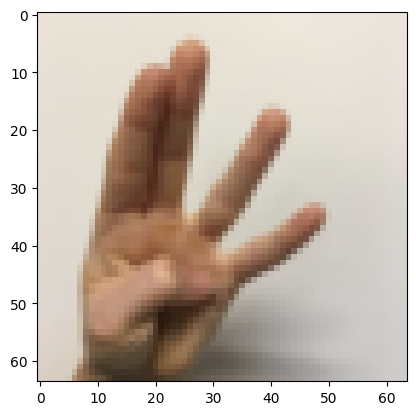

In [6]:
# Example of an image from the dataset
index = 9
plt.imshow(train_set_x_orig[index])
print ("y = " + str(np.squeeze(train_set_y_orig[index])))

### 1.2 - Convert all 1D -> 2D Array

We need to do that because it helps:
- **Easier for compute Loss**
- **Match with Output model**

**_Note:_** We do **NOT need** to **convert classes** because it does **NOT participate** in the **calculation** nor **input** for the **model**.

In [7]:
train_set_y_orig = train_set_y_orig.reshape((1, train_set_y_orig.shape[0]))
test_set_y_orig = test_set_y_orig.reshape((1, test_set_y_orig.shape[0]))
print("train_set_y_orig shape:", train_set_y_orig.shape)
print("test_set_y_orig shape:", test_set_y_orig.shape)

train_set_y_orig shape: (1, 1080)
test_set_y_orig shape: (1, 120)


### 1.3 - Convert Classes to One-Hot Representation

We need to know what the representation of classes is to know how we can convert it to One-hot representation.

In [8]:
print("Train: y = " + str(np.squeeze(train_set_y_orig)) + ", Size: " + str(train_set_y_orig.shape))

Train: y = [5 0 2 ... 2 4 5], Size: (1, 1080)


In [9]:
def convert_to_one_hot(Y, C):
    Y = np.eye(C)[Y.reshape(-1)].T
    return Y

### 1.4 - Split Data

Images are **64x64** pixels in RGB format (3 channels):
- **X_train/X_test shape**: `(batch_size, height, width, channels)`
- **Y_train/Y_test shape**: `(batch_size, #classes_one_hot_represent)`
- **Classes shape**: `(#classes,)`

In [10]:
# Normalize image vectors
X_train = train_set_x_orig/255.
X_test = test_set_x_orig/255.

# Reshape + Convert Y to One-hot
Y_train = convert_to_one_hot(train_set_y_orig, 6).T
Y_test = convert_to_one_hot(test_set_y_orig, 6).T

# Classes
classes = list_classes

print ("Number of training examples = " + str(X_train.shape[0]))
print ("Number of test examples = " + str(X_test.shape[0]))
print ("X_train shape: " + str(X_train.shape))
print ("Y_train shape: " + str(Y_train.shape))
print ("X_test shape: " + str(X_test.shape))
print ("Y_test shape: " + str(Y_test.shape))
print ("Classes shape: " + str(classes.shape))

Number of training examples = 1080
Number of test examples = 120
X_train shape: (1080, 64, 64, 3)
Y_train shape: (1080, 6)
X_test shape: (120, 64, 64, 3)
Y_test shape: (120, 6)
Classes shape: (6,)


## 2 - The Functional API

<font color="purple">

**_Definition_**:
- **Functional API:** Model is a **computational graph**, no longer a linear series. We can have:
    - Multiple inputs
    - Multiple outputs
    - Skip connection
    - Merge / split layer...

</font>

### 2.1 - Create the Functional Model Pipeline

Implement the `sign_digits_model` function below to build the following model:

<img src="images/Sign_Digits_Model.png">

Use the functions above!

Also, plug in the following parameters for all the steps:

 - [Conv2D](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Conv2D): Use 8 4 by 4 filters, stride 1, padding is "SAME"
 - [ReLU](https://www.tensorflow.org/api_docs/python/tf/keras/layers/ReLU)
 - [MaxPool2D](https://www.tensorflow.org/api_docs/python/tf/keras/layers/MaxPool2D): Use an 8 by 8 filter size and an 8 by 8 stride, padding is "SAME"
 - **Conv2D**: Use 16 2 by 2 filters, stride 1, padding is "SAME"
 - **ReLU**
 - **MaxPool2D**: Use a 4 by 4 filter size and a 4 by 4 stride, padding is "SAME"
 - [Flatten](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Flatten) the previous output.
 - Fully-connected ([Dense](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Dense)) layer: Apply a fully connected layer with 6 neurons and a softmax activation.

In [11]:
def signDigitsModel(input_shape):
    """
    Implements the forward propagation for the model

    Arguments:
    input_img -- input dataset, of shape (input_shape)

    Returns:
    model -- TF Keras model (object containing the information for the entire training process)
    """
    input_img = tfl.Input(shape=input_shape)

    # 1. Conv
    Z1 = tfl.Conv2D(8, 4, strides=(1, 1), padding='same')(input_img)

    # 2. ReLU
    A1 = tfl.ReLU()(Z1)

    # 3. MaxPool
    A1_pool = tfl.MaxPool2D(pool_size=(8, 8), strides=(8, 8), padding="same")(A1)

    # 4. Conv
    Z2 = tfl.Conv2D(16, 2, strides=(1, 1), padding='same')(A1_pool)

    # 5. ReLU
    A2 = tfl.ReLU()(Z2)

    # 6. MaxPool
    A2_pool = tfl.MaxPool2D(pool_size=(4, 4), strides=(4, 4), padding="same")(A2)

    # 7. Flatten
    F = tfl.Flatten()(A2_pool)

    # 8. Dense
    outputs = tfl.Dense(6, activation="softmax")(F)

    model = tf.keras.Model(inputs=input_img, outputs=outputs)
    return model

In [12]:
sign_digits_model = signDigitsModel((64, 64, 3))
sign_digits_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 8)      │           392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 64, 64, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 8, 8, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 16)       │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 2, 2, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,310 (5.12 KB)

 Trainable params: 1,310 (5.12 KB)

 Non-trainable params: 0 (0.00 B)

### 2.2 - Set up before Training

Before Training, we need to define:
- How to **Calculate Error**
- How to **Update Weight**
- How to **Measure Performance**

In [13]:
sign_digits_model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

### 2.3 - Train Model

In [14]:
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, Y_train)).batch(64)
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, Y_test)).batch(64)
history = sign_digits_model.fit(train_dataset, epochs=100, validation_data=test_dataset)

Epoch 1/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.1630 - loss: 1.8043 - val_accuracy: 0.1750 - val_loss: 1.7895
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.2241 - loss: 1.7873 - val_accuracy: 0.1917 - val_loss: 1.7806
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.2528 - loss: 1.7788 - val_accuracy: 0.2917 - val_loss: 1.7741
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3361 - loss: 1.7709 - val_accuracy: 0.2917 - val_loss: 1.7654
Epoch 5/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3278 - loss: 1.7616 - val_accuracy: 0.3500 - val_loss: 1.7569
Epoch 6/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3704 - loss: 1.7504 - val_accuracy: 0.4083 - val_loss: 1.7441
Epoch 7/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4037 - loss: 1.7361 - val_accuracy: 0.4000 - val_loss: 1.7304
Epoch 8/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4148 - loss: 1.7186 - val_accuracy: 0.425

## 3 - History Object

The **history object** is an **output** of the `.fit()` operation, and provides a **record** of all the **loss** and **metric values** in memory. It's **stored** as a **dictionary**.

In [15]:
history.history

{'accuracy': [0.16296295821666718,
  0.2240740805864334,
  0.2527777850627899,
  0.3361110985279083,
  0.32777777314186096,
  0.37037035822868347,
  0.4037036895751953,
  0.4148148000240326,
  0.4481481611728668,
  0.46203702688217163,
  0.4601851999759674,
  0.4611110985279083,
  0.4694444537162781,
  0.4833333194255829,
  0.489814817905426,
  0.5064814686775208,
  0.5138888955116272,
  0.5138888955116272,
  0.5277777910232544,
  0.5351851582527161,
  0.5509259104728699,
  0.5583333373069763,
  0.5638889074325562,
  0.574999988079071,
  0.5796296000480652,
  0.5861111283302307,
  0.6018518805503845,
  0.604629635810852,
  0.6111111044883728,
  0.625,
  0.6259258985519409,
  0.6342592835426331,
  0.6398147940635681,
  0.6490740776062012,
  0.6499999761581421,
  0.6555555462837219,
  0.664814829826355,
  0.6666666865348816,
  0.675000011920929,
  0.6787037253379822,
  0.6870370507240295,
  0.6898148059844971,
  0.6888889074325562,
  0.6953703761100769,
  0.7009259462356567,
  0.70833331

Now visualize the loss over time using `history.history`:

[Text(0.5, 0, 'Epoch'), Text(0, 0.5, 'Accuracy')]

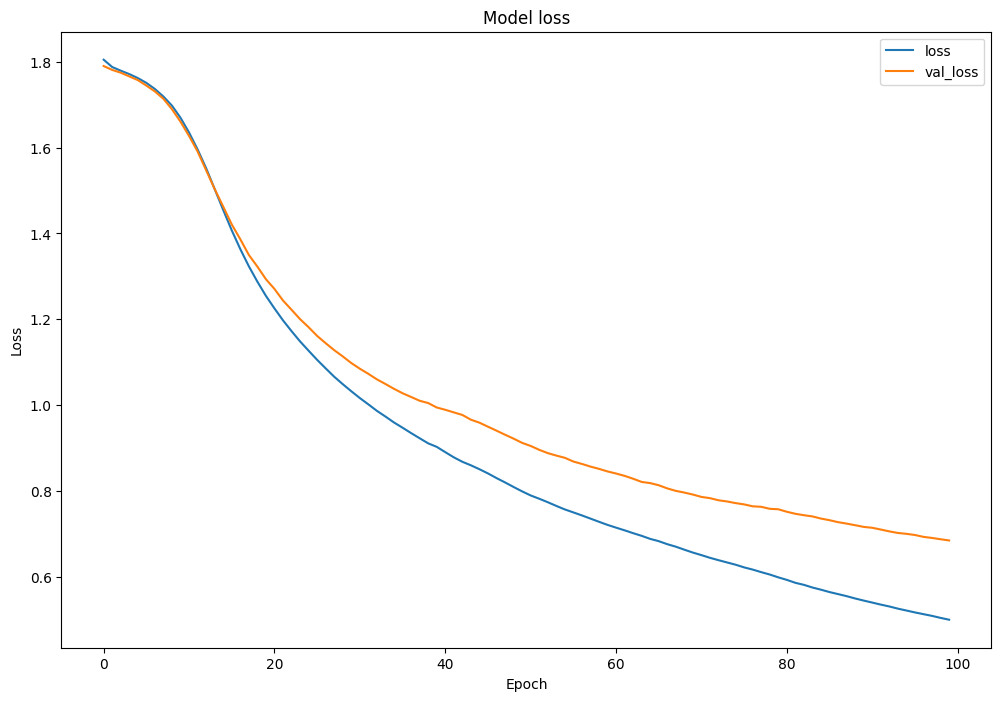

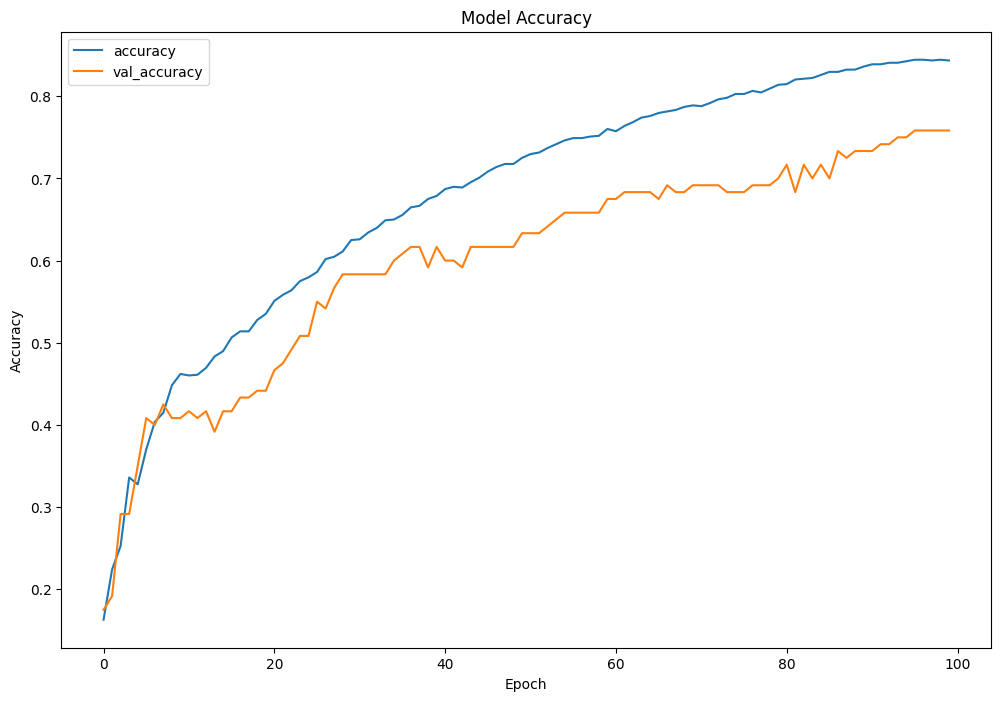

In [16]:
# The history.history["loss"] entry is a dictionary with as many values as epochs that the
# model was trained on.
df_loss_acc = pd.DataFrame(history.history)
df_loss= df_loss_acc[['loss','val_loss']]
df_loss.rename(columns={'loss':'train','val_loss':'validation'})
df_acc= df_loss_acc[['accuracy','val_accuracy']]
df_acc.rename(columns={'accuracy':'train','val_accuracy':'validation'})
df_loss.plot(title='Model loss',figsize=(12,8)).set(xlabel='Epoch',ylabel='Loss')
df_acc.plot(title='Model Accuracy',figsize=(12,8)).set(xlabel='Epoch',ylabel='Accuracy')